<a href="https://colab.research.google.com/github/sujitx-vs/Deep-Neural-Networks---PGCP_AI/blob/main/DNN_LAB_EXAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#PRACTICAL EXAMINATION
- Module: Deep Neural Networks
- You are provided the dataset "Multi-Class Prediction of Obesity Risk".

In [ ]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

## Part A: Data Loading & Sampling [2 Marks]
1. Load the dataset (Obesity_Risk.csv) using pandas.
2. Display the shape, first 5 rows, data types, and check for missing values and duplicates

In [ ]:
df = pd.read_csv('/content/DataSet.csv')
df.head() # first 5 rows

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,26.000000,1.649178,111.933010,yes,yes,3.000000,3.0,Sometimes,no,1.292479,no,0.065264,0.711331,Sometimes,Public_Transportation,Obesity_Type_III
1,Male,18.000000,1.750000,80.000000,no,yes,2.000000,3.0,Sometimes,no,2.000000,no,1.000000,1.000000,Sometimes,Public_Transportation,Overweight_Level_I
2,Female,23.360307,1.713380,84.722222,yes,yes,2.880161,3.0,Sometimes,no,2.847264,no,2.000000,0.002600,no,Public_Transportation,Obesity_Type_I
3,Male,30.002029,1.670667,112.000381,yes,yes,1.572036,3.0,Sometimes,no,2.003563,no,0.000000,0.114457,Sometimes,Public_Transportation,Obesity_Type_II
4,Male,17.000000,1.610000,50.000000,no,yes,2.000000,3.0,Sometimes,no,2.000000,no,0.000000,2.000000,no,Public_Transportation,Insufficient_Weight


- first 5 rows displayed.

In [ ]:
df.shape # Shape of the dataset

(20000, 17)

shape of the dataset 20000 x 17

In [ ]:
df.info() # overall info , with datatypes of coulmns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          20000 non-null  object 
 1   Age                             20000 non-null  float64
 2   Height                          20000 non-null  float64
 3   Weight                          20000 non-null  float64
 4   family_history_with_overweight  20000 non-null  object 
 5   FAVC                            20000 non-null  object 
 6   FCVC                            20000 non-null  float64
 7   NCP                             20000 non-null  float64
 8   CAEC                            20000 non-null  object 
 9   SMOKE                           20000 non-null  object 
 10  CH2O                            20000 non-null  float64
 11  SCC                             20000 non-null  object 
 12  FAF                             

Datatypes of different columns displayed.

In [ ]:
df.isna().sum() # missing values

,0
Gender,0
Age,0
Height,0
Weight,0
family_history_with_overweight,0
FAVC,0
FCVC,0
NCP,0
CAEC,0
SMOKE,0


No Null Values in the Dataset

In [ ]:
df.duplicated().sum()

np.int64(0)

No duplicate Values in the Dataset

## Part B: Exploratory Data Analysis [3 Marks]
1. Perform a thorough exploratory analysis of the sampled dataset.
2. Your EDA should reveal the distribution of obesity classes, relationships between lifestyle
features and obesity risk, and any patterns worth noting.
3. Support your analysis with appropriate visualisations and written observations

In [ ]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,23.824839,1.700463,87.916149,2.445488,2.760888,2.029500,0.983515,0.617167
std,5.656892,0.087334,26.390037,0.533674,0.705223,0.609079,0.838738,0.602031
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,20.000000,1.632118,66.000000,2.000000,3.000000,1.796257,0.008013,0.000000
50%,22.814657,1.700000,84.210535,2.392665,3.000000,2.000000,1.000000,0.573958
75%,26.000000,1.762921,111.635463,3.000000,3.000000,2.549617,1.596576,1.000000
max,61.000000,1.975663,165.057269,3.000000,4.000000,3.000000,3.000000,2.000000


In [ ]:
numerical_cols = df.select_dtypes("float64")
print("no of numerical columns = ",numerical_cols.shape[1])
numerical_cols.head()

no of numerical columns =  8


,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
0,26.000000,1.649178,111.933010,3.000000,3.0,1.292479,0.065264,0.711331
1,18.000000,1.750000,80.000000,2.000000,3.0,2.000000,1.000000,1.000000
2,23.360307,1.713380,84.722222,2.880161,3.0,2.847264,2.000000,0.002600
3,30.002029,1.670667,112.000381,1.572036,3.0,2.003563,0.000000,0.114457
4,17.000000,1.610000,50.000000,2.000000,3.0,2.000000,0.000000,2.000000


In [ ]:
categorical_cols = df.select_dtypes("object")
print("no of categorical columns = ",categorical_cols.shape[1])
categorical_cols.head()

no of categorical columns =  9


,Gender,family_history_with_overweight,FAVC,CAEC,SMOKE,SCC,CALC,MTRANS,NObeyesdad
0,Female,yes,yes,Sometimes,no,no,Sometimes,Public_Transportation,Obesity_Type_III
1,Male,no,yes,Sometimes,no,no,Sometimes,Public_Transportation,Overweight_Level_I
2,Female,yes,yes,Sometimes,no,no,no,Public_Transportation,Obesity_Type_I
3,Male,yes,yes,Sometimes,no,no,Sometimes,Public_Transportation,Obesity_Type_II
4,Male,no,yes,Sometimes,no,no,no,Public_Transportation,Insufficient_Weight


<Axes: >

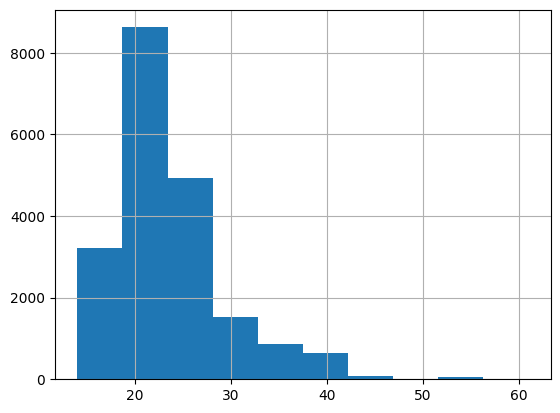

In [ ]:
df.Age.hist()

The whole data contains people from mainly the age group of 20-30.

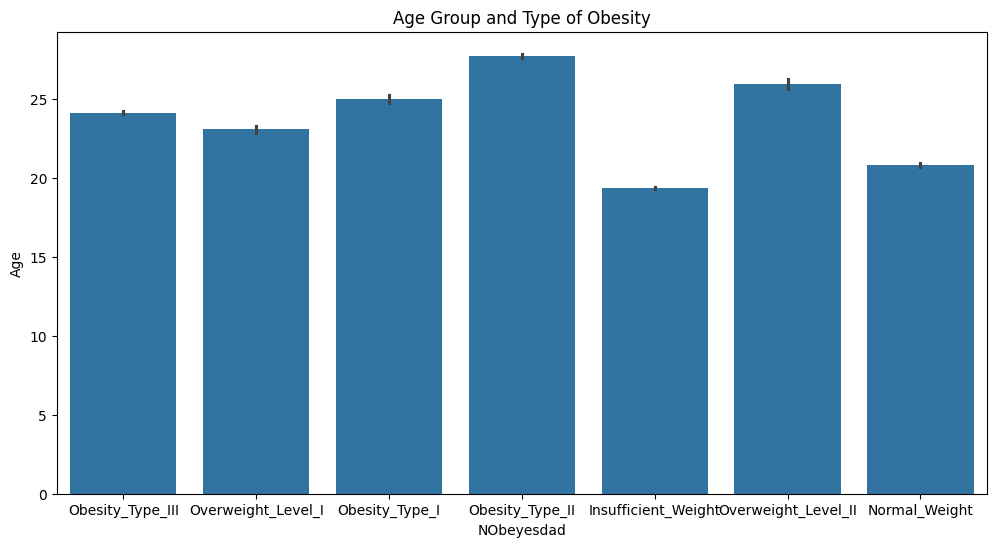

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(x = df['NObeyesdad'],y=df['Age'])
plt.title("Age Group and Type of Obesity")
plt.show()



This graph shows the different types of Obesity and the age group most occuring.

<Axes: >

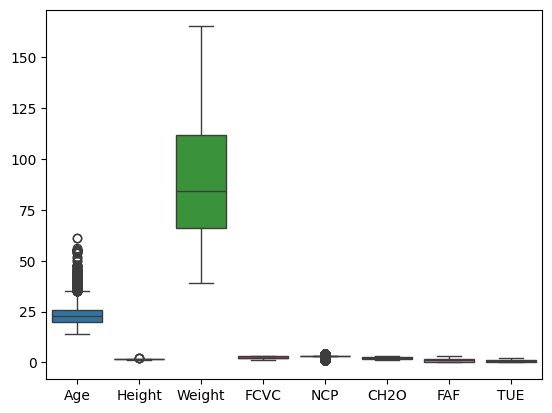

In [ ]:
sns.boxplot(df)

In [ ]:
lifestyle = df[['FAVC',"FCVC","NCP","CAEC","SMOKE","CALC","MTRANS"]]

##Part C: Data Preprocessing [2 Marks]
Prepare the data for model training.
1. Handle categorical variables, encoding the target variable, defining your feature set, and
applying appropriate scaling.
2. Justify any decisions you make during this step

In [ ]:
Y = df['NObeyesdad']
Y = LabelEncoder().fit_transform(Y)

In [ ]:
categorical_cols.nunique()

,0
Gender,2
family_history_with_overweight,2
FAVC,2
CAEC,4
SMOKE,2
SCC,2
CALC,3
MTRANS,5
NObeyesdad,7


One hot encoding for the values in Categorical columns that are less than 5

In [ ]:
categorical_cols.columns

Index(['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE',
       'SCC', 'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='object')

In [ ]:
categorical_cols = pd.get_dummies(categorical_cols[['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE',
       'SCC', 'CALC', 'MTRANS']],dtype="int")

In [ ]:
categorical_cols


,Gender_Female,Gender_Male,family_history_with_overweight_no,family_history_with_overweight_yes,FAVC_no,FAVC_yes,CAEC_Always,CAEC_Frequently,CAEC_Sometimes,CAEC_no,SMOKE_no,SMOKE_yes,SCC_no,SCC_yes,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,1,0,0,1,0,1,0,0,1,0,1,0,1,0,0,1,0,0,0,0,1,0
1,0,1,1,0,0,1,0,0,1,0,1,0,1,0,0,1,0,0,0,0,1,0
2,1,0,0,1,0,1,0,0,1,0,1,0,1,0,0,0,1,0,0,0,1,0
3,0,1,0,1,0,1,0,0,1,0,1,0,1,0,0,1,0,0,0,0,1,0
4,0,1,1,0,0,1,0,0,1,0,1,0,1,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,1,0,0,1,0,1,0,0,1,0,1,0,1,0,0,0,1,0,0,0,1,0
19996,0,1,0,1,0,1,0,0,1,0,1,0,1,0,0,1,0,0,0,0,1,0
19997,1,0,0,1,0,1,0,0,1,0,1,0,1,0,0,1,0,1,0,0,0,0
19998,0,1,0,1,0,1,0,0,1,0,1,0,1,0,0,1,0,0,0,0,1,0


In [ ]:
X = pd.concat([numerical_cols,categorical_cols],axis=1)

In [ ]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=.2,random_state=42)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
Y_train

array([4, 6, 6, ..., 0, 5, 2])

In [ ]:

Y_train = tf.keras.utils.to_categorical(Y_train, num_classes=7)
Y_test = tf.keras.utils.to_categorical(Y_test, num_classes=7)

## Part D: ANN Model Building & Training
Design and train an Artificial Neural Network suitable for this multi-class classification task.

In [ ]:
model = keras.Sequential([
    layers.Dense(64, activation='relu',input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(7, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)


In [ ]:
history = model.fit(X_train,Y_train,epochs=10,batch_size=32,validation_split=0.2)

Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6214 - loss: 1.0040 - val_accuracy: 0.7709 - val_loss: 0.6270
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7939 - loss: 0.5460 - val_accuracy: 0.8344 - val_loss: 0.4688
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8454 - loss: 0.4352 - val_accuracy: 0.8456 - val_loss: 0.4277
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8566 - loss: 0.3957 - val_accuracy: 0.8547 - val_loss: 0.4028
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8666 - loss: 0.3766 - val_accuracy: 0.8597 - val_loss: 0.4024
Epoch 6/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8701 - loss: 0.3646 - val_accuracy: 0.8616 - val_loss: 0.4009
Epoch 7/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8716 - loss: 0.3583 - val_accuracy: 0.8631 - val_loss: 0.3968
Epoch 8/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8720 - loss: 0.3517 - val_accuracy: 0.

##Part E: Prediction & Evaluation [3 Marks]
1. Generate predictions on the held-out test set and evaluate your model's performance
comprehensively.
2. Use metrics and visualisations appropriate for a multi-class classification problem.
3. Include a brief commentary on which classes were predicted well and which were not.

In [ ]:
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
loss, accuracy = model.evaluate(X_test, Y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy * 100:.2f}%")

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8668 - loss: 0.4122
Test Loss: 0.4122
Test Accuracy: 86.68%


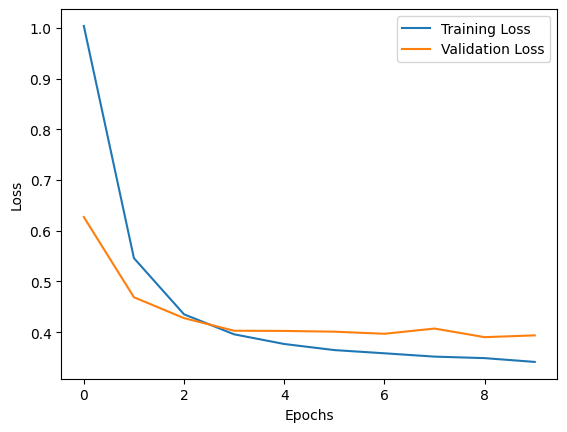

In [ ]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()